<a href="https://colab.research.google.com/github/Chitransh-Panwar/Fine-Tuning-EuroSAT/blob/main/Fine_tuning_ResNet_for_EuroSAT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
!rm -rf /content/EuroSAT

In [7]:
!cp -r /content/drive/MyDrive/EuroSAT /content/EuroSAT

In [8]:
import os
import pandas as pd
root="/content/EuroSAT"
pd.read_csv('/content/EuroSAT/train.csv').head()

,Unnamed: 0,Filename,Label,ClassName
0,16257,AnnualCrop/AnnualCrop_142.jpg,0,AnnualCrop
1,3297,HerbaceousVegetation/HerbaceousVegetation_2835...,2,HerbaceousVegetation
2,17881,PermanentCrop/PermanentCrop_1073.jpg,6,PermanentCrop
3,2223,Industrial/Industrial_453.jpg,4,Industrial
4,4887,HerbaceousVegetation/HerbaceousVegetation_1810...,2,HerbaceousVegetation


In [9]:
import json
train_df=pd.read_csv('/content/EuroSAT/train.csv')
val_df=pd.read_csv('/content/EuroSAT/validation.csv')
test_df=pd.read_csv('/content/EuroSAT/test.csv')
print(train_df.head())
print(train_df.shape, val_df.shape, test_df.shape)
with open('/content/EuroSAT/label_map.json') as f:
  label_map=json.load(f)
print(label_map)


   Unnamed: 0                                           Filename  Label  \
0       16257                      AnnualCrop/AnnualCrop_142.jpg      0   
1        3297  HerbaceousVegetation/HerbaceousVegetation_2835...      2   
2       17881               PermanentCrop/PermanentCrop_1073.jpg      6   
3        2223                      Industrial/Industrial_453.jpg      4   
4        4887  HerbaceousVegetation/HerbaceousVegetation_1810...      2   

              ClassName  
0            AnnualCrop  
1  HerbaceousVegetation  
2         PermanentCrop  
3            Industrial  
4  HerbaceousVegetation  
(18900, 4) (5400, 4) (2700, 4)
{'AnnualCrop': 0, 'Forest': 1, 'HerbaceousVegetation': 2, 'Highway': 3, 'Industrial': 4, 'Pasture': 5, 'PermanentCrop': 6, 'Residential': 7, 'River': 8, 'SeaLake': 9}


<PIL.Image.Image image mode=RGB size=64x64 at 0x78A13D5BD940> (64, 64)


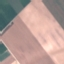

In [10]:
from PIL import Image
from torch.utils.data import Dataset

class EuroSATCSVDataset(Dataset):
  def __init__(self,csv_path,root_dir,transform=None):
    self.df=pd.read_csv(csv_path)
    self.root_dir=root_dir
    self.transform=transform

  def __len__(self):
    return len(self.df)

  def __getitem__(self,idx):
    row=self.df.iloc[idx]
    img_path=os.path.join(self.root_dir,row['Filename'])
    image=Image.open(img_path).convert('RGB')
    label=int(row['Label'])
    if self.transform:
      image=self.transform(image)
    return image,label
root='/content/EuroSAT'
test_dataset=EuroSATCSVDataset(os.path.join(root,'train.csv'),root)
img,label=test_dataset[0]
print(img,img.size)
img

In [11]:
from torchvision import transforms
train_transform=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225])
])

eval_transform=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225])
])

In [12]:
train_dataset=EuroSATCSVDataset(os.path.join(root,'train.csv'),root,transform=train_transform)
val_dataset=EuroSATCSVDataset(os.path.join(root,'validation.csv'),root,transform=eval_transform)
test_dataset=EuroSATCSVDataset(os.path.join(root,'test.csv'),root,transform=eval_transform)


In [13]:
from torch.utils.data import DataLoader

train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
val_loader=DataLoader(val_dataset,batch_size=32,shuffle=False)
test_loader=DataLoader(test_dataset,batch_size=32,shuffle=False)

In [14]:
import torchvision.models as models
import torch.nn as nn

model=models.resnet50(weights='IMAGENET1K_V2')

for param in model.parameters():
  param.requires_grad=False

num_features=model.fc.in_features
model.fc=nn.Linear(num_features,10)

model=model.to('cuda')
trainable=sum(p.numel() for p in model.parameters() if p.requires_grad)
total=sum(p.numel() for p in model.parameters())


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 189MB/s]


In [15]:
import torch.optim as optim
from tqdm import tqdm
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.fc.parameters(),lr=0.001)
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}'):
        images = images.to('cuda')
        labels = labels.to('cuda')

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to('cuda')
            labels = labels.to('cuda')
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_accuracy = correct / total
    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(train_loader):.4f}, Val Accuracy: {val_accuracy:.4f}')

Epoch 1: 100%|██████████| 591/591 [01:37<00:00,  6.05it/s]


Epoch 1/10, Loss: 0.6435, Val Accuracy: 0.8906


Epoch 2: 100%|██████████| 591/591 [01:38<00:00,  6.00it/s]


Epoch 2/10, Loss: 0.3494, Val Accuracy: 0.9102


Epoch 3: 100%|██████████| 591/591 [01:38<00:00,  6.02it/s]


...

Epoch 8/10, Loss: 0.2056, Val Accuracy: 0.9380


Epoch 9: 100%|██████████| 591/591 [01:38<00:00,  6.02it/s]


Epoch 9/10, Loss: 0.1979, Val Accuracy: 0.9359


Epoch 10: 100%|██████████| 591/591 [01:37<00:00,  6.04it/s]


Epoch 10/10, Loss: 0.1901, Val Accuracy: 0.9381


In [16]:
for param in model.parameters():
  param.requires_grad=True

optimizer=optim.Adam(model.parameters(),lr=0.0001)

In [17]:
num_epochs=10
for epoch in range(num_epochs):
  model.train()
  running_loss=0.0
  for images,labels in tqdm(train_loader,desc=f'fine-tuning epoch {epoch+1}'):
    images=images.to('cuda')
    labels=labels.to('cuda')
    optimizer.zero_grad()
    outputs=model(images)
    loss=criterion(outputs,labels)
    loss.backward()
    optimizer.step()
    running_loss+=loss.item()
  model.eval()
  correct=0
  total=0
  with torch.no_grad():
    for images,labels in val_loader:
      images=images.to('cuda')
      labels=labels.to('cuda')
      outputs=model(images)
      _,predicted=torch.max(outputs,1)
      total+=labels.size(0)
      correct+=(predicted==labels).sum().item()
  val_accuracy=correct/total
  torch.save(model.state_dict(),f'/content/drive/MyDrive/EuroSAT_checkpoint_epoch{epoch+1}.pt')
  print(f'Fine-tune Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(train_loader):.4f}, Val Accuracy: {val_accuracy:.4f}')


fine-tuning epoch 1: 100%|██████████| 591/591 [03:47<00:00,  2.60it/s]


Fine-tune Epoch 1/10, Loss: 0.1355, Val Accuracy: 0.9720


fine-tuning epoch 2: 100%|██████████| 591/591 [03:46<00:00,  2.61it/s]


Fine-tune Epoch 2/10, Loss: 0.0791, Val Accuracy: 0.9657


fine-tuning epoch 3: 100%|██████████| 591/591 [03:46<00:00,  2.61it/s]


...

Fine-tune Epoch 8/10, Loss: 0.0254, Val Accuracy: 0.9793


fine-tuning epoch 9: 100%|██████████| 591/591 [03:46<00:00,  2.61it/s]


Fine-tune Epoch 9/10, Loss: 0.0221, Val Accuracy: 0.9828


fine-tuning epoch 10: 100%|██████████| 591/591 [03:45<00:00,  2.62it/s]


Fine-tune Epoch 10/10, Loss: 0.0208, Val Accuracy: 0.9813


In [ ]:
from sklearn.metrics import classification_report ,confusion_matrix
import numpy as np

model.eval()
all_preds=[]
all_labels=[]

with torch.no_grad():
  for images,labels in tqdm(test_loader,desc='Testing'):
    images=images.to('cuda')
    outputs=model(images)
    _,predicted=torch.max(outputs,1)
    all_preds.extend(predicted.cpu().numpy())
    all_labels.extend(labels.numpy())

class_names = ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial',
               'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
print(classification_report(all_labels, all_preds, target_names=class_names))
